<a href="https://colab.research.google.com/github/Noorumms/sms_email-spam-classifier/blob/main/SMS_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [112]:
import numpy as np
import pandas as pd


In [113]:
df = pd.read_csv('/content/sample_data/spam.csv', encoding='latin-1')

In [114]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
256,ham,Mmm so yummy babe ... Nice jolt to the suzy,NaN,NaN,NaN
1780,spam,BIG BROTHER ALERT! The computer has selected u...,NaN,NaN,NaN
3649,ham,"We are hoping to get away by 7, from Langport....",NaN,NaN,NaN
1442,ham,"Its ok., i just askd did u knw tht no?",NaN,NaN,NaN
93,spam,Please call our customer service representativ...,NaN,NaN,NaN


In [115]:
df.shape


(5572, 5)

# Stages:
- Data Cleaning
- EDA
- Data(Text) Preprocessing
- Model Building
- Evaluation
- Improvements
- Website
- Deployment

# 1.Data Cleaning

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


drop last 3 cols


In [117]:
df.drop(columns= ['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace = True )

In [118]:
df.sample(5)

,v1,v2
3183,ham,Good morning pookie pie! Lol hope I didn't wak...
4525,spam,"I want some cock! My hubby's away, I need a re..."
3456,ham,Friendship poem: Dear O Dear U R Not Near But ...
836,spam,Do you want 750 anytime any network mins 150 t...
677,ham,"Piggy, r u awake? I bet u're still sleeping. I..."


renaming cols

In [119]:
df.rename(columns={'v1':'target','v2':'text'},inplace = True)
df.sample(5)

,target,text
2856,ham,Today i'm not workin but not free oso... Gee.....
1580,ham,"I shall book chez jules for half eight, if tha..."
2429,spam,Guess who am I?This is the first time I create...
2166,ham,"Thank you. And by the way, I just lost."
4320,ham,"K, jason says he's gonna be around so I'll be ..."


In [120]:
# we need numbers in target instead of ham and spam

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


In [121]:
df['target'] =encoder.fit_transform(df['target'])

In [122]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [123]:
#check missing values

df.isnull().sum()

,0
target,0
text,0


In [124]:
#check for duplicate values

df.duplicated().sum()

np.int64(403)

In [125]:
#remove duplicates

df = df.drop_duplicates(keep ='first')

In [126]:
df.shape

(5169, 2)

# 2.EDA (EXPLORATORY DATA ANALYSIS)

In [127]:


df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [128]:
#check for percentage of ham and spam
#running value counts

df['target'].value_counts()

,count
target,
0,4516
1,653


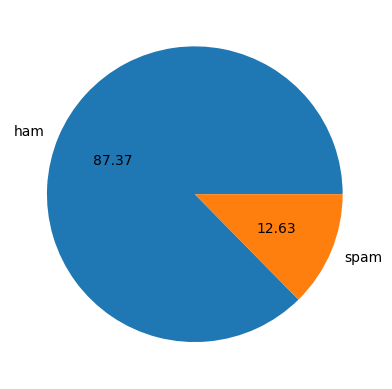

In [129]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

#autp pct to see percentage 0.2f - 2 values after point

In datset about 87.37 percent sms are ham and spam is only 12.63 % so
*data is imbalanced*



In [130]:
#counting number of characters in each message
df['num_characters']=df['text'].apply(len)

#now a new col of num_characters is added to dataset


In [131]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [132]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [133]:
#Fecting num of words using nltk
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [134]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [135]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [136]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [137]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [138]:
#ham messages

df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [139]:
#spam messages

df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Hostogram plotting

In [140]:
import seaborn as sns

Histogram for ham

<Axes: xlabel='num_characters', ylabel='Count'>

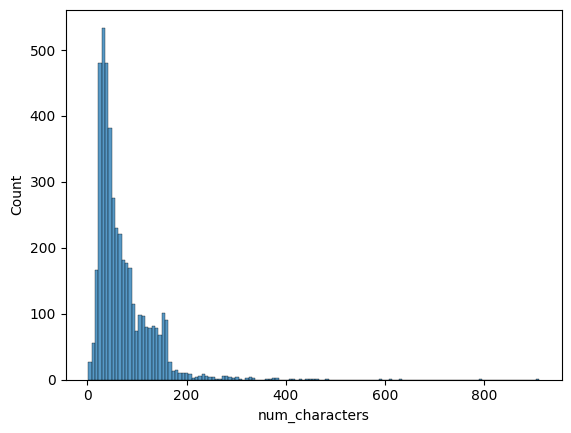

In [141]:
sns.histplot(df[df['target']==0]['num_characters'])

Histogram for spam

<Axes: xlabel='num_characters', ylabel='Count'>

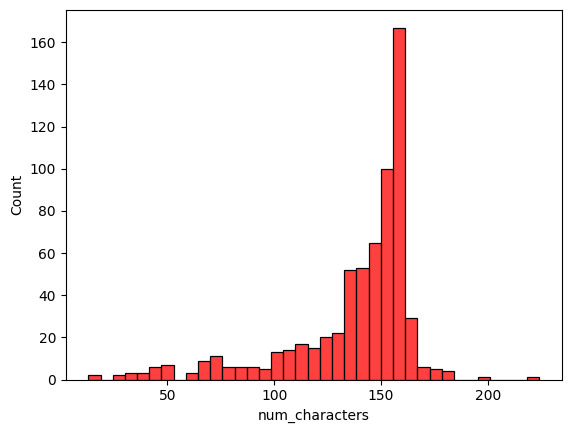

In [142]:
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_characters', ylabel='Count'>

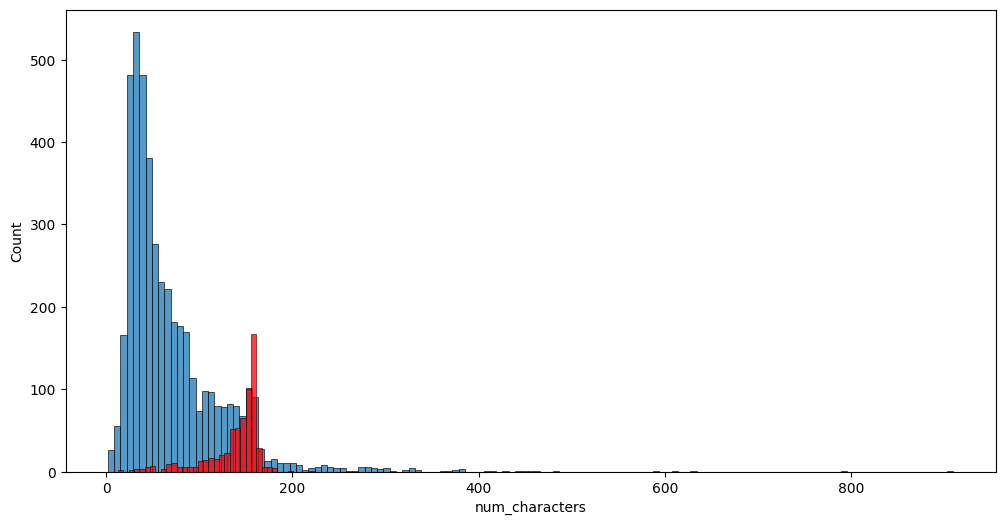

In [143]:
plt.figure(figsize =(12,6) )

sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

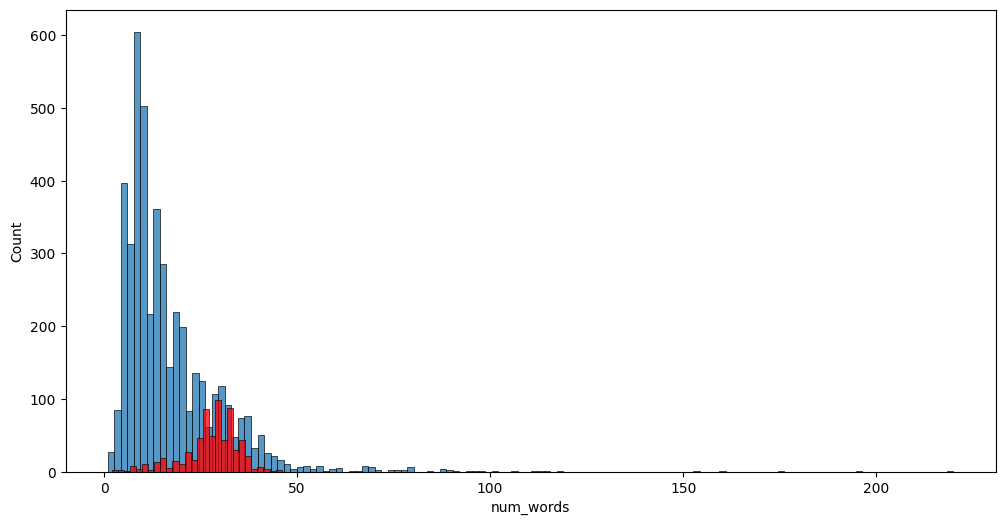

In [144]:
plt.figure(figsize =(12,6) )

sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

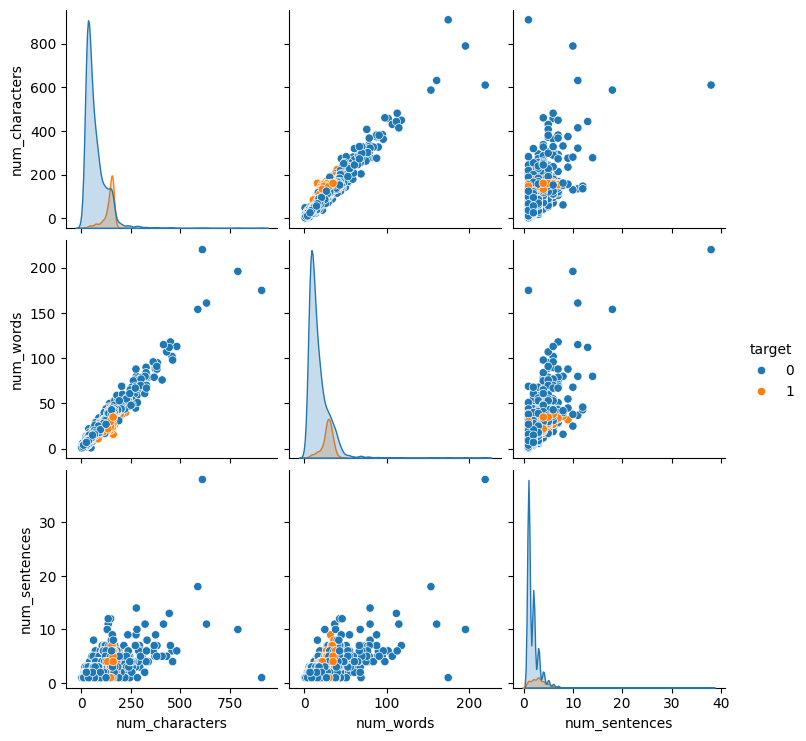

In [145]:
sns.pairplot(df,hue='target')
plt.show()

In [146]:
df_corr = df.corr(numeric_only=True)

<Axes: >

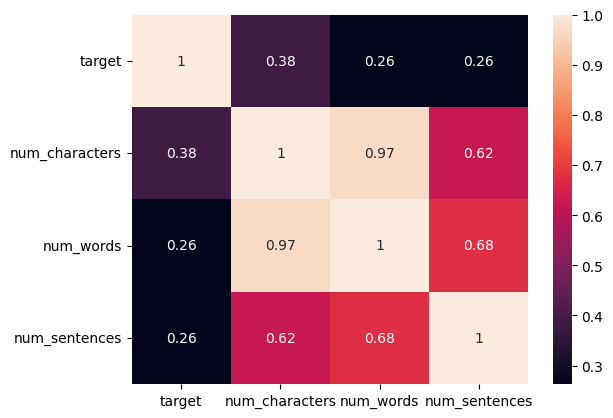

In [147]:
sns.heatmap(df_corr,annot = True)

 Tendency of message to be  (target = 1) spam will increase as value is closer to 1

 num_characters is most close to 1 w.r.t target(target =1 (spam)

## 3.Data PreProcessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [148]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text) #breaking down words sentence in words

  #keeping words only that are alphanumeric (alphabets /numeric)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)


  text = y[:] #cloning as we cannot simply copy list as text = y
  #as list is mutable  datatype so we need to do cloning as text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y) # returns the words in form tring joining through space

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')#brings words in root form dancing - danc

In [149]:
txt = df['text'][0]

In [150]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [151]:
df['text'].apply(transform_text)

,text
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
2,free entri 2 wkli comp win fa cup final tkt 21...
3,u dun say earli hor u c alreadi say
4,nah think goe usf live around though
...,...
5567,2nd time tri 2 contact u pound prize 2 claim e...
5568,b go esplanad fr home
5569,piti mood suggest
5570,guy bitch act like interest buy someth els nex...


In [152]:
df['transformed_text']=df['text'].apply(transform_text)

In [153]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


WORD CLOUD OF Ham and SPAM MESSAGES

In [154]:
from wordcloud import WordCloud
wc = WordCloud(width = 500,height=500,min_font_size=10,background_color ='white')

In [155]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

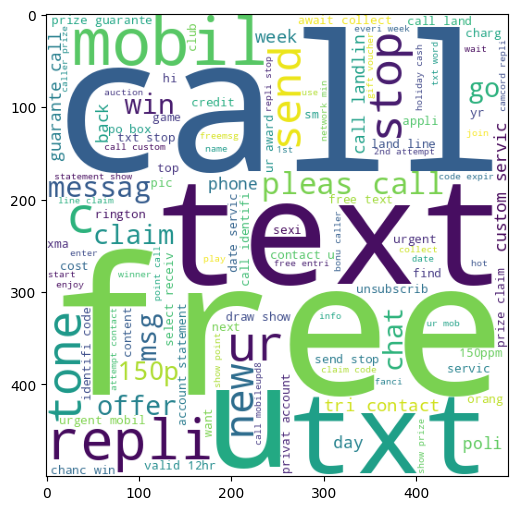

In [156]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

word cloud for ham messages

In [157]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

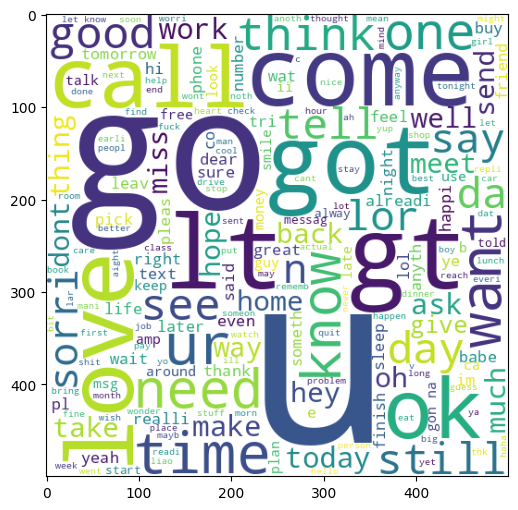

In [158]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [159]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


top 50 words used in messages

In [160]:
spam_corpus=[]

df_list=df[df['target']==1]['transformed_text'].tolist()
#list of strings and each message is an item
for msg in df_list:
  for word in msg.split():
    spam_corpus.append(word)


In [161]:
len(spam_corpus)

9939

In [162]:
from collections import Counter
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30))

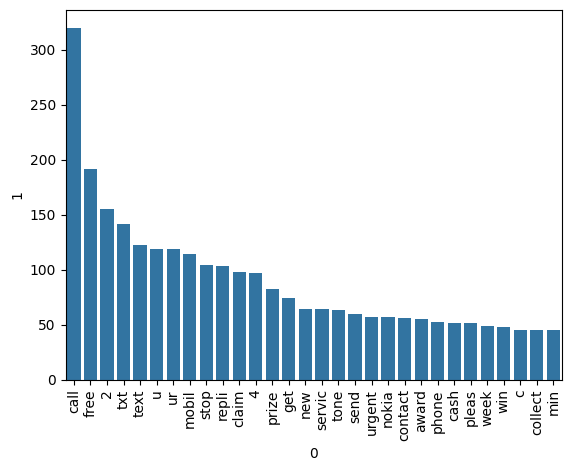

In [163]:
sns.barplot(x=most_common_df[0], y=most_common_df[1])
plt.xticks(rotation='vertical')
plt.show()

helps in data analysis
EDA Helps in understanding of problem and how the model is predicting answer

In [164]:
ham_corpus=[]

df_ham_list=df[df['target']==0]['transformed_text'].tolist()
#list of strings and each message is an item
for msg in df_ham_list:
  for word in msg.split():
    ham_corpus.append(word)

In [165]:
len(ham_corpus)

35404

In [166]:
from collections import Counter
most_common_df = pd.DataFrame(Counter(ham_corpus).most_common(30))

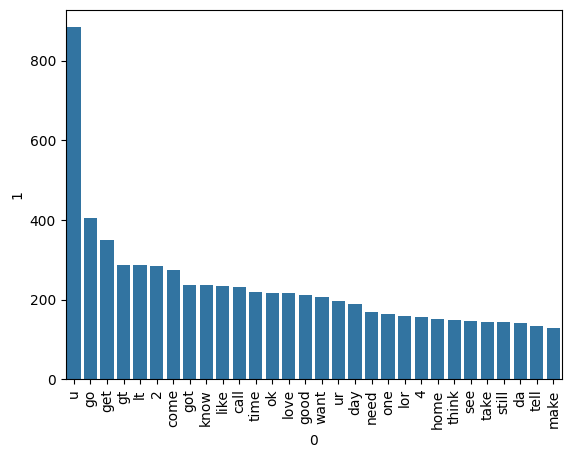

In [167]:
sns.barplot(x=most_common_df[0], y=most_common_df[1])
plt.xticks(rotation='vertical')
plt.show()

# 4.Model Building

For textual data naive based algorithm model is best (best performance for textual data)

Any ml model needs numerical data

our target is in numbers but text is in text

//vectroize text (to convert text to numbers )

ways of vectorizing text data
- bag of words -> we make col of freq word then check each message how many times that frequnt words occurs and it starts giving numbers so those numbers become vectors

- TFIDF

- Word to vec

1.vectorize data(text)
(bag of words)

In [168]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

#we are doing this after all models rain test
# we are restrcting max_features for model improvement

tfidf = TfidfVectorizer(max_features=3000)

In [169]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [ ]:
##2.(Seond model imp)scaled x for model improvemnt 2nd part of model improvent

#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)


##there was no improvemrnt in model precision but it dropped precision
##we will not add scalingfor model improvement

In [197]:
##3. For model improvement
#appending the num_character col to x

X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))



In [198]:
X.shape
#(sms,words)

(5169, 6709)

In [171]:
y= df['target'].values

2.Vectizing throgh TFIDF

In [172]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [173]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [174]:
y= df['target'].values

In [175]:
from sklearn.model_selection import train_test_split

train test slit of X(I/p) and y(o/) by 80(train):20(test)

In [176]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2)

In [177]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [178]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [179]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [180]:
gnb.fit(X_train,y_train)
y_pred1= gnb.predict(X_test)
ac_score= accuracy_score(y_test,y_pred1)
print(ac_score)
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8558994197292069
[[776 134]
 [ 15 109]]
0.448559670781893


In [181]:
mnb.fit(X_train,y_train)
y_pred2= mnb.predict(X_test)
ac_score= accuracy_score(y_test,y_pred2)
print(ac_score)
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

#precison - 1.0 means 0 false positives and 0 false negatives

0.9642166344294004
[[910   0]
 [ 37  87]]
1.0


In [182]:
bnb.fit(X_train,y_train)
y_pred3= bnb.predict(X_test)
ac_score= accuracy_score(y_test,y_pred3)
print(ac_score)
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9709864603481625
[[905   5]
 [ 25  99]]
0.9519230769230769


we want more precision as data is imbalanced so precision matters more than accuracy

In [183]:
#tfidf ----> MNB


In [184]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [185]:
svc = SVC(kernel = 'sigmoid',gamma = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear',penalty = 'l1')
rfc = RandomForestClassifier(n_estimators =50,random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50,random_state = 2)
bc = BaggingClassifier(n_estimators = 50,random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50,random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50,random_state = 2)
xgb = XGBClassifier(n_estimators = 50,random_state = 2)
#

In [186]:
#dictionary with keys- algo name and values - key objects
clfs={
     'SVC':svc,
     'KN' :knc,
     'NB':mnb,
     'DT':dtc,
     'LR':lrc,
     'RF':rfc,
     'AdaBoost':abc,
     'BgC':bc,
     'ETC':etc,
     'GBDT':gbdt,
     'xgb':xgb
 }

In [187]:
#training data py classifier ko train kr rha hai
def train_classifier(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred= clf.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred)
  return accuracy,precision

In [188]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9805825242718447)

In [189]:
accuracy_scores =[]
precision_scores = []

for name,clf in clfs.items():
  current_accuracy,current_precision = train_classifier(clf,X_train,y_train,X_test,y_test)


  print("For ",name)
  print("Accuracy - ",current_accuracy)
  print("Precision - ",current_precision)

  accuracy_scores.append(current_accuracy)
  precision_scores.append(current_precision)


For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9805825242718447
For  KN
Accuracy -  0.9110251450676983
Precision -  1.0
For  NB
Accuracy -  0.9642166344294004
Precision -  1.0
For  DT
Accuracy -  0.9352030947775629
Precision -  0.8
For  LR
Accuracy -  0.9535783365570599
Precision -  0.9222222222222223
For  RF
Accuracy -  0.971953578336557
Precision -  0.9797979797979798
For  AdaBoost
Accuracy -  0.9332688588007737
Precision -  0.8313253012048193
For  BgC
Accuracy -  0.9574468085106383
Precision -  0.8571428571428571
For  ETC
Accuracy -  0.9758220502901354
Precision -  0.9805825242718447
For  GBDT
Accuracy -  0.9555125725338491
Precision -  0.9333333333333333
For  xgb
Accuracy -  0.9729206963249516
Precision -  0.9363636363636364


In [190]:
performance_df = pd.DataFrame({'Algorithm': clfs.keys(),'Accuracy': accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending = False)

In [196]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.911025,1.000000
2,NB,0.964217,1.000000
0,SVC,0.975822,0.980583
8,ETC,0.975822,0.980583
5,RF,0.971954,0.979798
10,xgb,0.972921,0.936364
9,GBDT,0.955513,0.933333
4,LR,0.953578,0.922222
7,BgC,0.957447,0.857143
6,AdaBoost,0.933269,0.831325


In [192]:
performance_df1 = pd.melt(performance_df,id_vars="Algorithm")

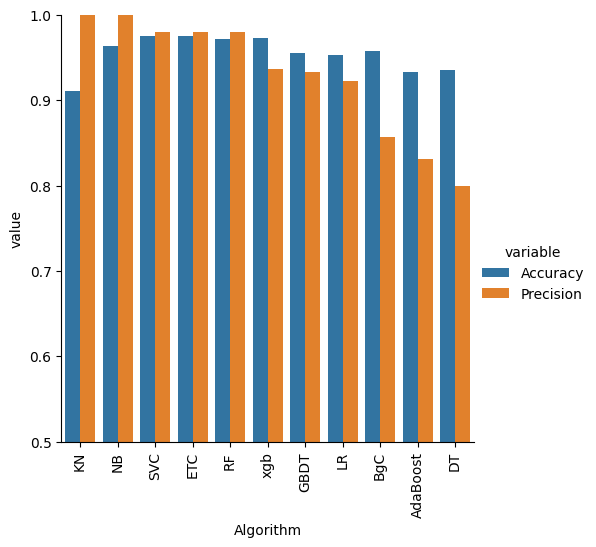

In [193]:
sns.catplot(x='Algorithm',y='value',
            hue = 'variable',data= performance_df1,kind='bar',height = 5)
plt.ylim(0.5,1.0)
plt.xticks(rotation= 'vertical')
plt.show()

# Model Improvement

In [194]:
#1.Change the max_features parameter of Tfidf
#when we are vectorizing for tfdif max_features = for how many words
#you want to vectorize ,we can restrict max_features
#if we give max_ features = 3000 so most common 3000 words  vectorizes

#2.SCALED the x on where we applied tfidf transform

#3. For model improvement
#appending the num_character col to x
#didn't improve much

#4.Voting classifier
#best performing models ka combination then see i this combination outperforms the best
#Naive bayes
#no improvement

#5.ScalingClassifier
# no improvent

#final verdict we will use mnb


In [201]:
#voting classifier
svc = SVC(kernel = 'sigmoid',gamma=1.0,probability = True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators = 50,random_state = 2)
#
from sklearn.ensemble import VotingClassifier

In [203]:
voting = VotingClassifier(estimators= [('svm',svc),('nb',mnb),('et',etc)],voting='soft')

In [204]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [205]:
VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                             probability = True)),
                             ('nb', MultinomialNB()),
                              ('et', ExtraTreesClassifier(n_estimators=50,
                                                          random_state= 2))],
                                                          voting = 'soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [207]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 1.0


In [209]:
#Applying stacking
#in voting all 3 models have equla say

##in stacking we decide weightage of all three models
#using a final estimator which is RF in this case

estimators = [('svm',svc),('nb',mnb),('et',etc)]
final_estimator = RandomForestClassifier()

In [210]:
from sklearn.ensemble import StackingClassifier

In [211]:
clf = StackingClassifier(estimators=estimators,
                         final_estimator=final_estimator)

In [213]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
#

Accuracy 0.9874274661508704
Precision 0.9743589743589743


## Pipeline

3 steps
- tranform text gives text after preproceeing
- vectorize transformed text
- Algorithm application on vectorixeed text


In [216]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))